# Shot Overview Demo

This notebook is a thin example for the reusable shot-overview plotting API. It loads cached diagnostics, prints compact summaries, and renders a manually windowed overview plot.


## Configuration

The cache path is explicit so this example uses existing `local/bh-molecule/` files and never triggers downloads.


In [1]:
from pathlib import Path

from lhd_data.plotting.helpers import (
    DEFAULT_OVERVIEW_DIAGNOSTICS,
    load_cached_diagnostics,
    summarize_datasets,
)
from lhd_data.plotting.overview import plot_shot_overview
from lhd_data.plotting.summary import describe_halpha, describe_thomson

SHOT = 193809
CACHE_DIR = Path("../local/bh-molecule")
DIAGNOSTICS = DEFAULT_OVERVIEW_DIAGNOSTICS


## Cached Dataset Summary

The summary is intentionally compact for quick exploration.


In [2]:
datasets, failed = load_cached_diagnostics(SHOT, DIAGNOSTICS, cache_dir=CACHE_DIR)
print(summarize_datasets(datasets, failed, diagnostics=DIAGNOSTICS))
print()
print(describe_thomson(datasets.get("thomson")))
print()
print(describe_halpha(datasets))


wp                  OK  vars=3  time=127081
bolo                OK  vars=2  time=13105
nbpwr_tot_temporal  OK  vars=17  time=131072
fircall             OK  vars=15  time=1311
thomson             OK  vars=15  time=389  shape=(Time,R)
ha1                 OK  vars=4  time=12001
ha2                 OK  vars=21  time=1310

thomson:
  Te -> (time, R)
  n_e -> (time, R)

Thomson:
coordinates:
Time: shape=(389,), units=ms
R: shape=(140,), units=mm

signals:
Te: dims=(Time, R), shape=(389, 140), units=eV
n_e: dims=(Time, R), shape=(389, 140), units=10^16 m^-3


## Overview Plot

`tmin` and `tmax` are manual seconds. `show_nbi`, `halpha_mode`, and `te_ylim` keep the quick-look figure readable without automatic analysis.


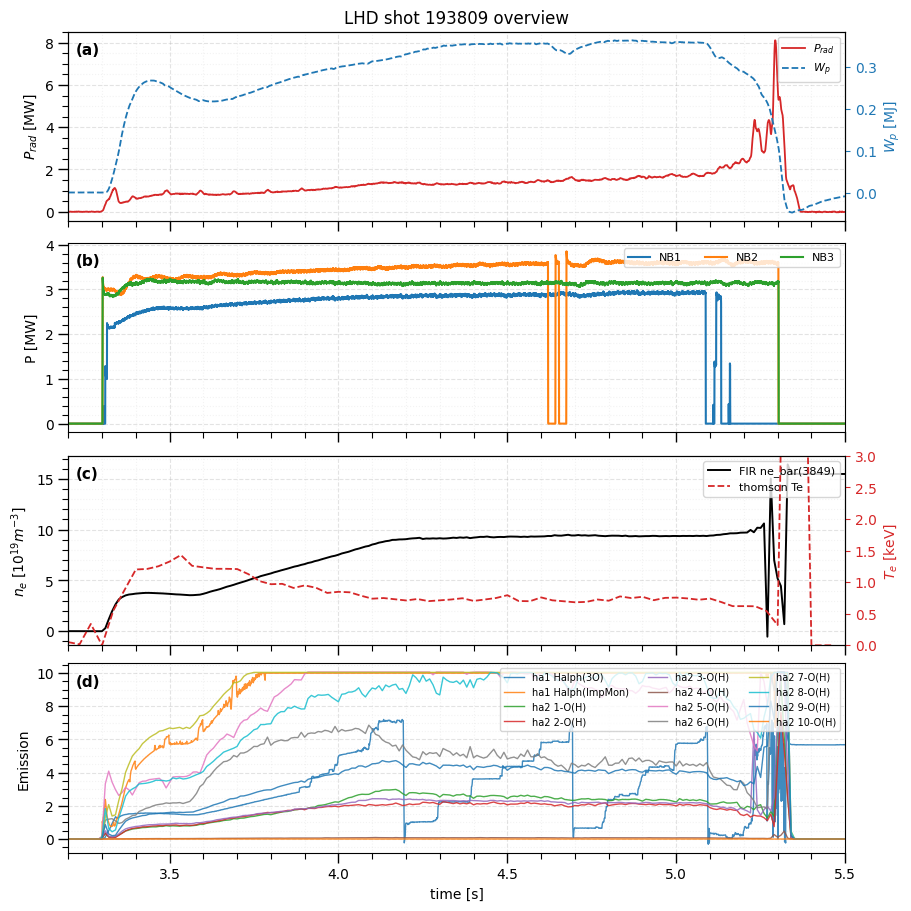

In [5]:
fig, axes = plot_shot_overview(
    shot=193809,
    cache_dir=CACHE_DIR,
    tmin=3.2,
    tmax=5.5,
    show_nbi=[1, 2, 3],
    halpha_mode="all",
    te_ylim=(0, 3),
)

In [6]:
from lhd_data.plotting.summary import describe_halpha, describe_thomson

print(describe_halpha(datasets))

ImportError: cannot import name 'describe_halpha' from 'lhd_data.plotting.summary' (C:\Users\queezz\Dropbox\20-Code\2026-LHD\src\lhd_data\plotting\summary.py)